In [20]:
import numpy as np
import matplotlib.pyplot as plt

## 2.a.  
We say $Z_t$ is WN iif $\mathbb{E}(Z_t)=0$ and $\mathbb{V}(Z_t)=1$. Therefore, we set $Z_t = \frac{D_t - \mathbb{E}(D_t)}{\operatorname{sd}(D_t)}$ with  
$\mathbb{E}(D_t) = 3.5$  
$\operatorname{sd}(D_t) = 1.7$

In [28]:
def WNdice(N):
    sd = np.sqrt( 2*(2.5**2 + 1.5**2 + 0.5**2)/6 )
    E = 3.5
    D_t = np.random.randint(1,7, size = N)
    Z_t = (D_t - E)/sd
    return Z_t

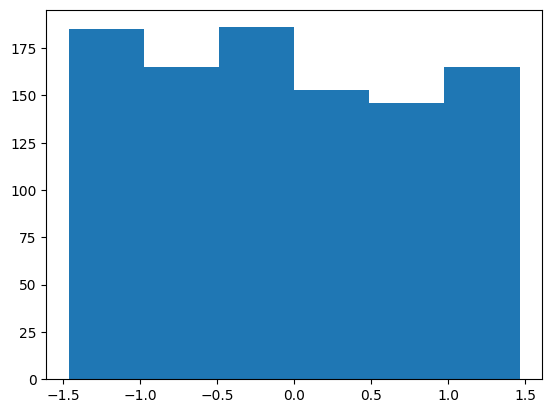

In [29]:
plt.hist(WNdice(1000), bins = 6)
plt.show()

## 2.b.

In [259]:
def GARCH11path(N, burn_in, a0, a1, b, WN='WNdice'):
    X = np.zeros(N+burn_in)
    sigma = np.zeros(N+burn_in)
    X[0] = 0
    sigma[0] = 1

    if WN == 'WNdice':
        Z = WNdice(N+burn_in)
    if WN == 'WNnormal':
        Z = np.random.normal(size=N+burn_in)
    if WN == 'WNt':
        Z = np.random.standard_t(3,size=N+burn_in)

    for i in range(1, N+burn_in):
        sigma[i] = np.sqrt(a0 + a1*X[i-1]**2 + b*sigma[i-1]**2)
        X[i] = sigma[i]*Z[i]
    
    return X[burn_in:], sigma[burn_in:]

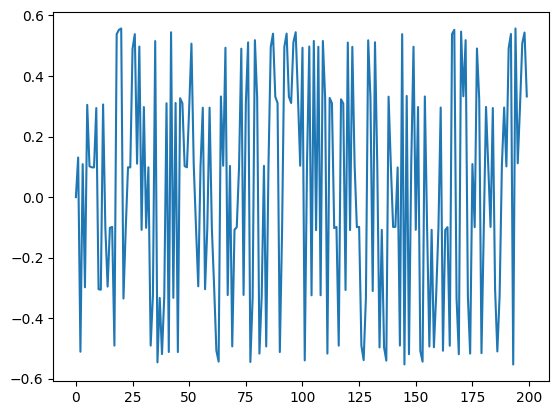

In [185]:
plt.plot(GARCH11path(N=200, burn_in=0, a0=0.1, a1=0.1, b=0.1)[0])

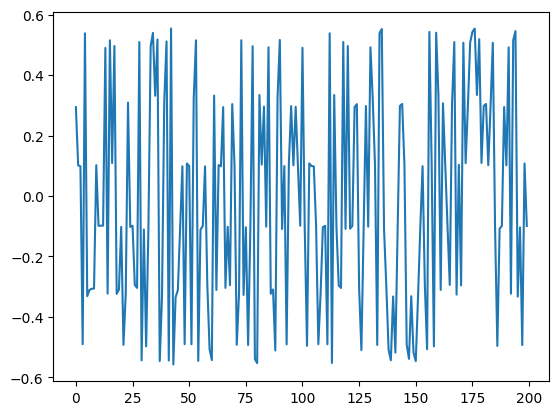

In [182]:
plt.plot(GARCH11path(N=200, burn_in=1000, a0=0.1, a1=0.1, b=0.1)[0])

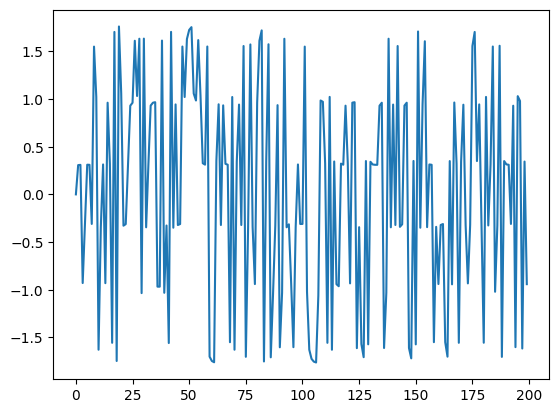

In [173]:
plt.plot(GARCH11path(N=200, burn_in=0, a0=1, a1=0.1, b=0.1)[0])

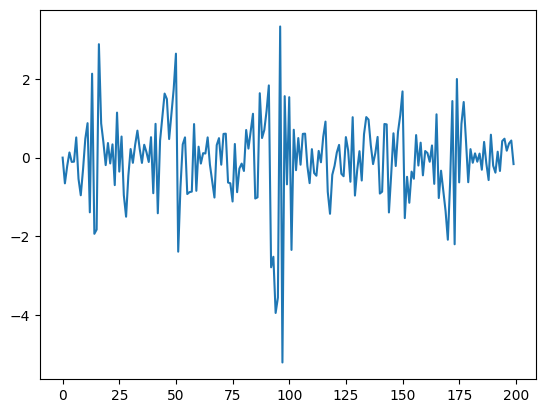

In [181]:
plt.plot(GARCH11path(N=200, burn_in=0, a0=0.1, a1=1, b=0.1)[0])

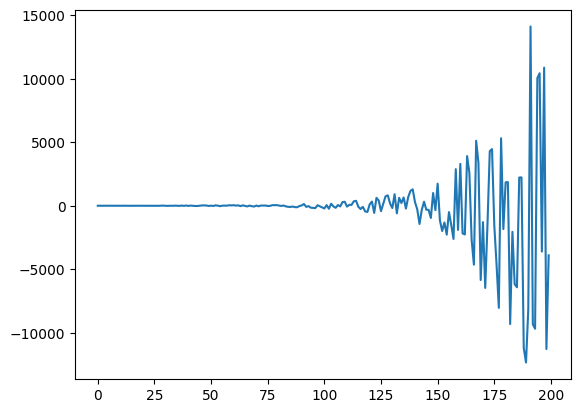

In [179]:
plt.plot(GARCH11path(N=200, burn_in=0, a0= 0.1, a1=0.1, b=1)[0])

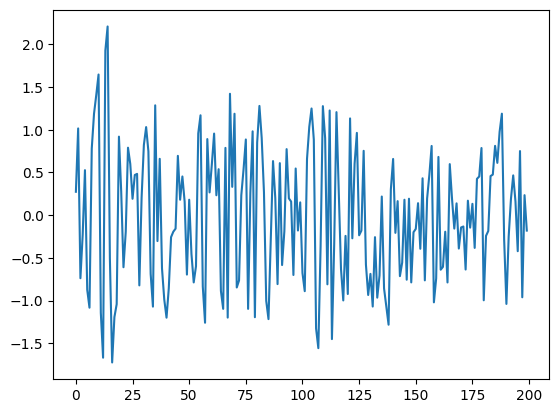

In [251]:
plt.plot(GARCH11path(N=200, burn_in=1000, a0=0.1, a1=0.4, b=0.4)[0])

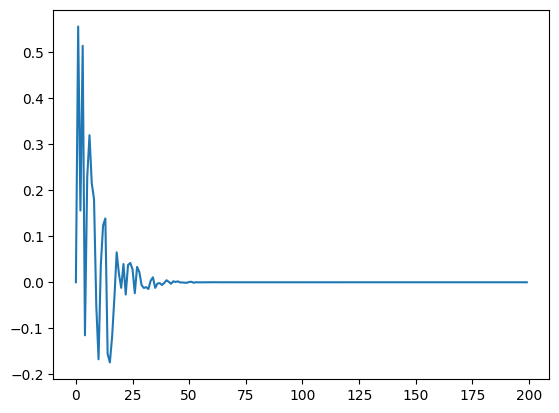

In [254]:
plt.plot(GARCH11path(N=200, burn_in=0, a0=0, a1=0.4, b=0.4)[0])

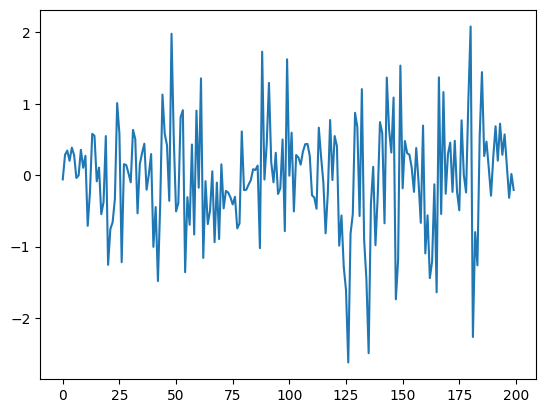

In [261]:
plt.plot(GARCH11path(N=200, burn_in=10000, a0=0.1, a1=0.4, b=0.4, WN='WNnormal')[0])

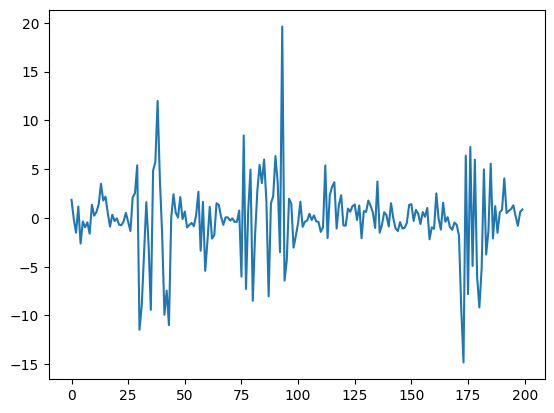

In [ ]:
plt.plot(GARCH11path(N=200, burn_in=10000, a0=0.1, a1=0.4, b=0.4, WN='WNt')[0]) #for df = 1 or 2, the process is not stationary.

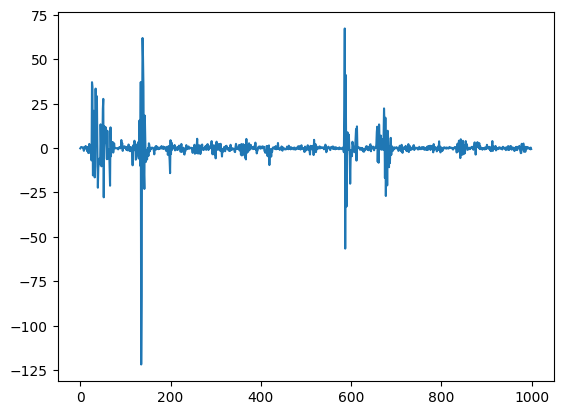

In [276]:
plt.plot(GARCH11path(N=1000, burn_in=10000, a0=0.1, a1=0.4, b=0.4, WN='WNt')[0]) #wildcard, sometimes very reasonably looking plot, sometimes reaches 2000 in a volatility cluster.

## 5